In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import trustworthiness
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import umap

In [53]:
df=pd.read_excel('Данные_для_курсовои_Классическое_МО.xlsx')
df.head(3)

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0


In [54]:
df = df.drop(columns=['Unnamed: 0'])

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


In [56]:
df.shape

(1001, 213)

In [57]:
#проверяем пропуски
missing = df.isnull().sum()
total_rows = len(df)
print(f'Колонок с пропусками: {(missing > 0).sum()}')
missing_data = missing[missing > 0].to_frame(name="Missing Count")
missing_data["Missing Percentage"] = (missing_data["Missing Count"] / total_rows) * 100

missing_data

Колонок с пропусками: 12


,Missing Count,Missing Percentage
MaxPartialCharge,3,0.2997
MinPartialCharge,3,0.2997
MaxAbsPartialCharge,3,0.2997
MinAbsPartialCharge,3,0.2997
BCUT2D_MWHI,3,0.2997
BCUT2D_MWLOW,3,0.2997
BCUT2D_CHGHI,3,0.2997
BCUT2D_CHGLO,3,0.2997
BCUT2D_LOGPHI,3,0.2997
BCUT2D_LOGPLOW,3,0.2997


In [58]:
df = df.dropna()
df.shape

(998, 213)

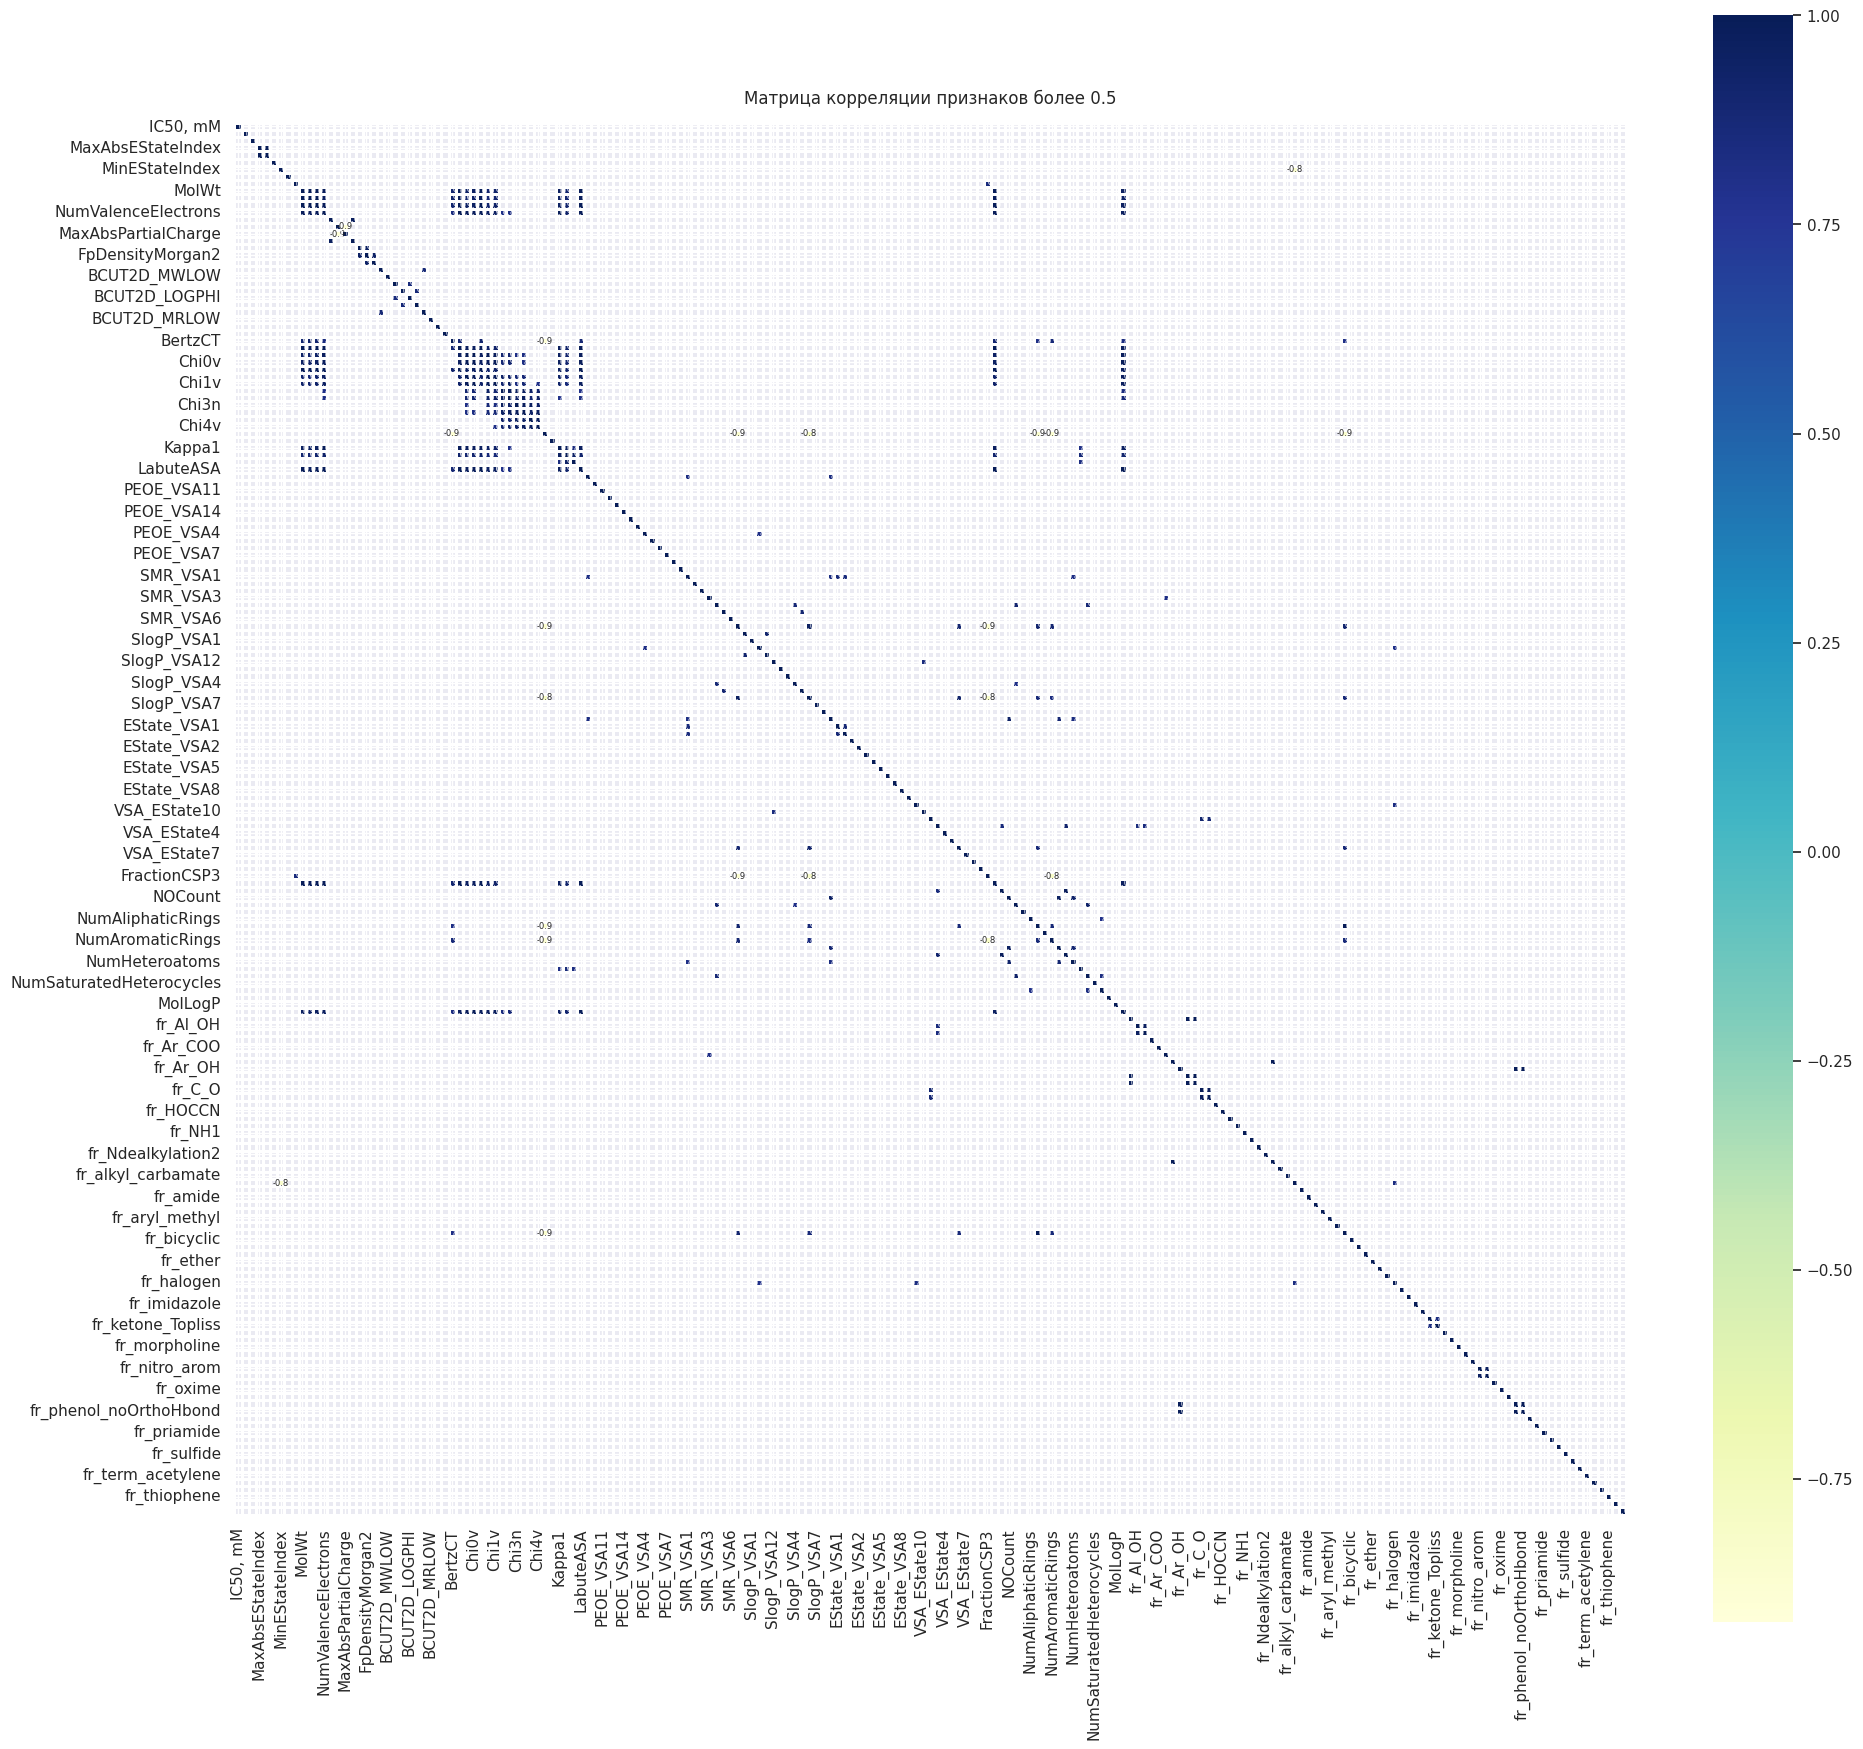

In [59]:
corr_matrix = df.corr(numeric_only=True)
mask = np.abs(corr_matrix) < 0.8
corr_filtered = corr_matrix.where(~mask, np.nan)
corr_filtered = corr_filtered.dropna(how='all', axis=0)
corr_filtered = corr_filtered.dropna(how='all', axis=1)
sns.set(rc={'figure.figsize': (20, 18)})
sns.heatmap(corr_filtered, annot=True, cmap="YlGnBu", linecolor='white', fmt='.1f', linewidths=1, square=True,annot_kws={'size': 6})
plt.title('Матрица корреляции признаков более 0.5', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

видим достаточно много признаков которые имеют сильную корреляцию друг с другом, изучим их более детально

In [60]:
#корреялция между признаками
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            print(f"{corr_matrix.columns[i]:25} | {corr_matrix.columns[j]:25} | {corr_val:.2f}")

MaxAbsEStateIndex         | MaxEStateIndex            | 1.00
MinEStateIndex            | fr_alkyl_halide           | -0.85
SPS                       | FractionCSP3              | 0.85
MolWt                     | HeavyAtomMolWt            | 1.00
MolWt                     | ExactMolWt                | 1.00
MolWt                     | NumValenceElectrons       | 0.98
MolWt                     | BertzCT                   | 0.90
MolWt                     | Chi0                      | 0.99
MolWt                     | Chi0n                     | 0.93
MolWt                     | Chi0v                     | 0.95
MolWt                     | Chi1                      | 0.99
MolWt                     | Chi1n                     | 0.90
MolWt                     | Chi1v                     | 0.93
MolWt                     | Kappa1                    | 0.96
MolWt                     | Kappa2                    | 0.91
MolWt                     | LabuteASA                 | 0.99
MolWt                  

видим много признаков, которые имеют сильную связь с другими - удалим эти столбцы

In [61]:
high_corr_cols = ['HeavyAtomMolWt', 'ExactMolWt', 'HeavyAtomCount', 'fr_benzene', 'fr_COO2', 'fr_Al_OH_noTert', 'fr_phenol_noOrthoHbond', 'fr_nitro_arom_nonortho','NumValenceElectrons', 'Chi0', 'Chi1', 'LabuteASA', 'HeavyAtomCount', 'MolMR', 'Chi0n', 'Chi0v', 'Chi1n', 'Chi1v','Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v','Kappa2', 'Kappa3','SMR_VSA7', 'SlogP_VSA6', 'SlogP_VSA11',
    'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA10', 'SlogP_VSA12', 'VSA_EState6', 'VSA_EState10', 'VSA_EState1', 'VSA_EState2', 'VSA_EState3','EState_VSA1', 'EState_VSA10','fr_Al_COO', 'fr_COO', 'fr_phenol', 'fr_Ar_OH', 'fr_Ar_NH', 'fr_Nhpyrrole', 'fr_C_O_noCOO',
    'fr_ketone_Topliss', 'fr_nitro_arom', 'fr_Ar_N','NOCount', 'NumHAcceptors', 'NumHeteroatoms', 'NHOHCount', 'NumHDonors', 'fr_Al_OH', 'NumAliphaticCarbocycles', 'NumSaturatedCarbocycles','NumAliphaticRings', 'NumSaturatedRings']

In [62]:
df = df.drop(columns=high_corr_cols, errors='ignore')

In [63]:
df.shape

(998, 154)

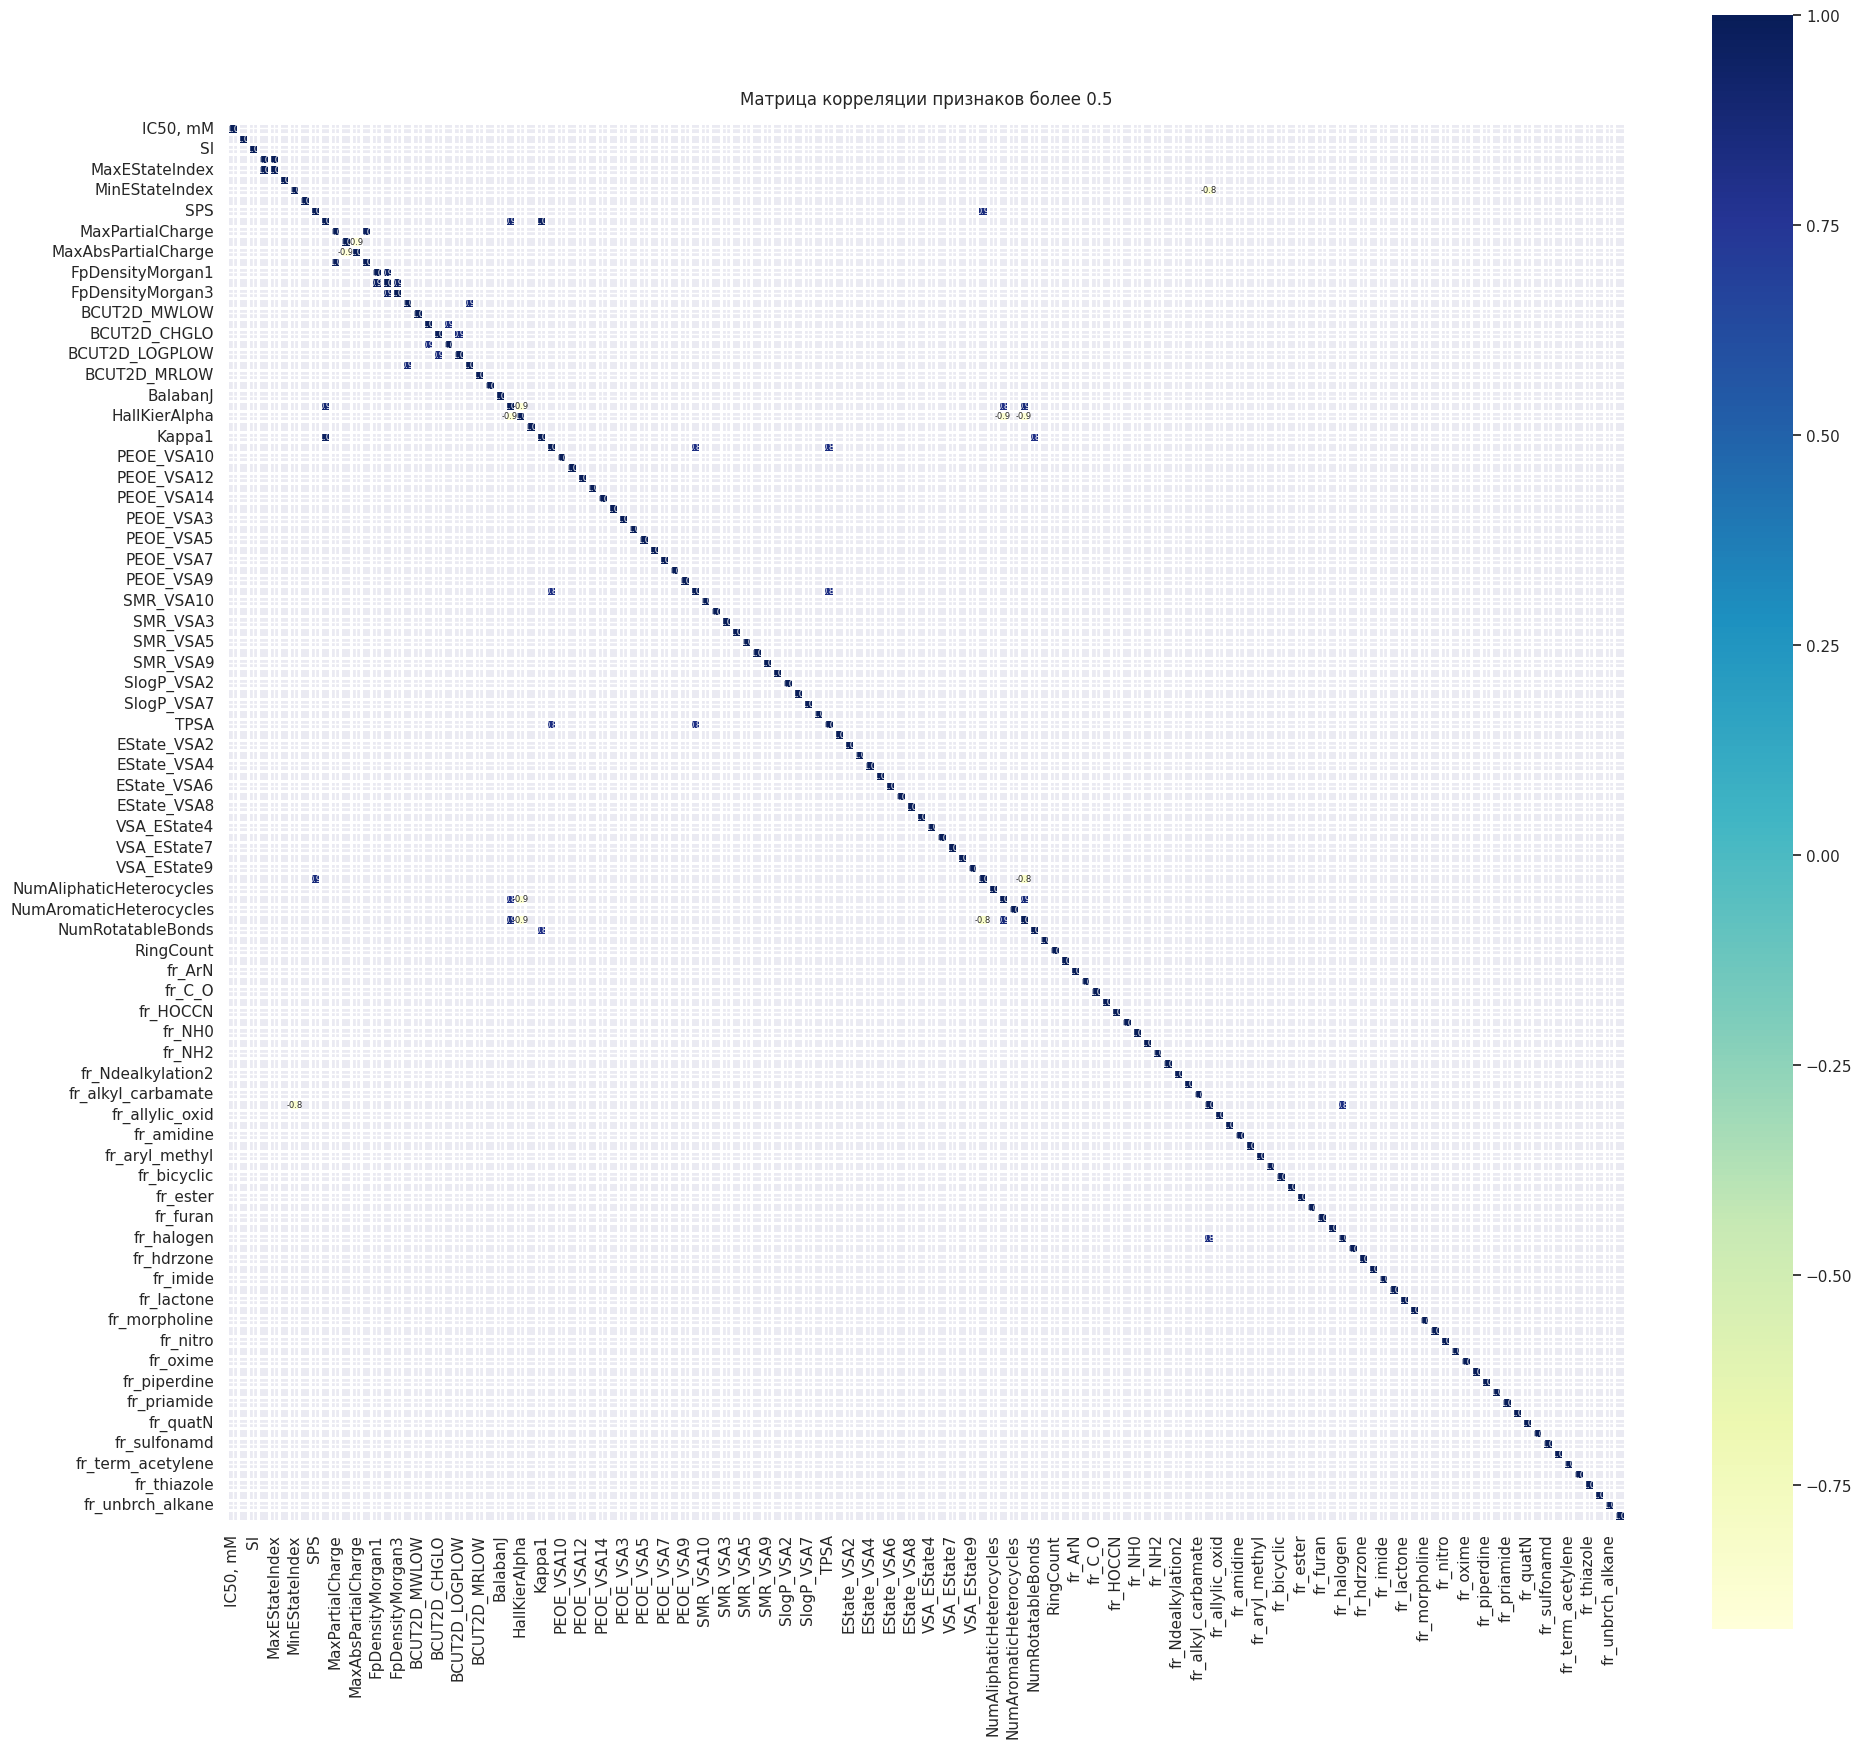

In [64]:
corr_matrix = df.corr(numeric_only=True)
mask = np.abs(corr_matrix) < 0.8
corr_filtered = corr_matrix.where(~mask, np.nan)
corr_filtered = corr_filtered.dropna(how='all', axis=0)
corr_filtered = corr_filtered.dropna(how='all', axis=1)
sns.set(rc={'figure.figsize': (20, 18)})
sns.heatmap(corr_filtered, annot=True, cmap="YlGnBu", linecolor='white', fmt='.1f', linewidths=1, square=True,annot_kws={'size': 6})
plt.title('Матрица корреляции признаков более 0.5', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

In [65]:
df.describe()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,...,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.0,998.000000,998.000000,998.000000
mean,221.118757,586.668414,72.650005,10.829292,10.829292,0.180888,-0.966330,0.581179,29.539854,348.525023,...,0.053106,0.012024,0.009018,0.001002,0.001002,0.052104,0.0,0.070140,0.205411,0.007014
std,400.510657,642.016454,685.504279,3.312200,3.312200,0.168860,1.590258,0.212081,12.726557,127.045802,...,0.257652,0.109048,0.094582,0.031654,0.031654,0.222349,0.0,0.255511,1.217101,0.083497
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.491340,99.999036,1.457233,9.050397,9.050397,0.051003,-1.332714,0.442842,18.533333,264.321000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,45.992006,408.793314,3.856410,12.187546,12.187546,0.124656,-0.419485,0.635772,29.374328,315.457000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,224.408630,891.770961,16.525000,13.172207,13.172207,0.291678,0.065482,0.742483,38.801136,409.435250,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [66]:
df_new = df.copy()
#объединяем похожие функциональные группы и создаем один признак
groups = groups = {
    'fr_aromatic': ['fr_benzene', 'fr_pyridine', 'fr_furan', 'fr_thiophene', 'fr_imidazole', 'fr_oxazole'],
    'fr_acidic': ['fr_COO', 'fr_Al_COO', 'fr_Ar_COO', 'fr_phos_acid'],
    'fr_basic': ['fr_aniline', 'fr_piperdine', 'fr_piperzine', 'fr_Imine'],
    'fr_hbd': ['fr_Al_OH', 'fr_Ar_OH', 'fr_NH0', 'fr_NH1', 'fr_NH2'],
    'fr_hba': ['fr_ether', 'fr_ester', 'fr_ketone', 'fr_amide', 'fr_nitrile'],
    'fr_halogen': ['fr_halogen', 'fr_alkyl_halide'],
    'fr_sulfur': ['fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_thiazole', 'fr_thiophene', 'fr_thiocyan'],
    'fr_nitro': ['fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho'],
    'fr_rings': ['fr_benzene', 'fr_pyridine', 'fr_furan', 'fr_thiophene', 'fr_imidazole',
                 'fr_morpholine', 'fr_piperdine', 'fr_piperzine'],}
for group_name, group_cols in groups.items():
    existing_cols = [col for col in group_cols if col in df.columns]
    if existing_cols:
        df_new[f'sum_{group_name}'] = df[existing_cols].sum(axis=1)
        print(f'Создан: sum_{group_name} (из {len(existing_cols)} признаков)')
#сумма всех функциональных групп и счетчик этих групп (пытаемся понять молекула сложная или простая)
fr_cols = [col for col in df.columns if col.startswith('fr_')]
df_new['sum_all_fr'] = df[fr_cols].sum(axis=1)
df_new['active_fr'] = (df[fr_cols] > 0).sum(axis=1)
print(f'Создан: sum_all_fr (из {len(fr_cols)} признаков)')
print(f'Создан: active_fr (из {len(fr_cols)} признаков)')
#заменяем группу признаков Estate электронное состояние на статистические параметры состояния каждого электрона в молекуле
estate_cols = [col for col in df.columns if col.startswith('EState_')]
if estate_cols:
    df_new['mean_estate'] = df[estate_cols].mean(axis=1)
    df_new['max_estate'] = df[estate_cols].max(axis=1)
    df_new['min_estate'] = df[estate_cols].min(axis=1)
    df_new['range_estate'] = df_new['max_estate'] - df_new['min_estate']
    df_new['std_estate'] = df[estate_cols].std(axis=1)
    print(f"Созданы агрегации EState (из {len(estate_cols)} признаков)")
#объединяем все площади молекулы в 3 призанка VSA (общая площадь поверхности молекулы, среднее своство молекулы и разнообразие свойств молекулы)
vsa_cols = [col for col in df.columns if 'VSA' in col]
if vsa_cols:
    df_new['sum_vsa'] = df[vsa_cols].sum(axis=1)
    df_new['mean_vsa'] = df[vsa_cols].mean(axis=1)
    df_new['std_vsa'] = df[vsa_cols].std(axis=1)
    print(f"Созданы агрегации VSA (из {len(vsa_cols)} признаков)")
#объединяем данные по гидрофобности в 2 признака общая гидрофобность и средняя гидрофобность молекулы
slogp_cols = [col for col in df.columns if col.startswith('SlogP_')]
if slogp_cols:
    df_new['sum_slogp'] = df[slogp_cols].sum(axis=1)
    df_new['mean_slogp'] = df[slogp_cols].mean(axis=1)
    print(f"Созданы агрегации SlogP (из {len(slogp_cols)} признаков)")
#удаляем колонки
useful_original = ['qed', 'SPS', 'FractionCSP3', 'BalabanJ', 'AvgIpc', 'Ipc',
                   'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
                   'HeavyAtomCount', 'NumRadicalElectrons', 'HallKierAlpha', 'Kappa1',
                   'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge']
cols_to_drop = [col for col in df_new.columns
                if not col.startswith(('sum_', 'active_', 'mean_', 'max_', 'min_', 'range_', 'std_'))
                and col not in useful_original
                and col not in ['IC50, mM', 'CC50, mM', 'SI']]

df_final = df_new.drop(columns=cols_to_drop)


Создан: sum_fr_aromatic (из 5 признаков)
Создан: sum_fr_acidic (из 2 признаков)
Создан: sum_fr_basic (из 4 признаков)
Создан: sum_fr_hbd (из 3 признаков)
Создан: sum_fr_hba (из 5 признаков)
Создан: sum_fr_halogen (из 2 признаков)
Создан: sum_fr_sulfur (из 6 признаков)
Создан: sum_fr_nitro (из 1 признаков)
Создан: sum_fr_rings (из 7 признаков)
Создан: sum_all_fr (из 69 признаков)
Создан: active_fr (из 69 признаков)
Созданы агрегации EState (из 9 признаков)
Созданы агрегации VSA (из 43 признаков)
Созданы агрегации SlogP (из 6 признаков)


In [67]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 0 to 1000
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   IC50, mM                  998 non-null    float64
 1   CC50, mM                  998 non-null    float64
 2   SI                        998 non-null    float64
 3   qed                       998 non-null    float64
 4   SPS                       998 non-null    float64
 5   NumRadicalElectrons       998 non-null    int64  
 6   MaxPartialCharge          998 non-null    float64
 7   MinPartialCharge          998 non-null    float64
 8   MaxAbsPartialCharge       998 non-null    float64
 9   MinAbsPartialCharge       998 non-null    float64
 10  AvgIpc                    998 non-null    float64
 11  BalabanJ                  998 non-null    float64
 12  HallKierAlpha             998 non-null    float64
 13  Ipc                       998 non-null    float64
 14  Kappa1        

In [68]:
#создаем отдельные массивы с целевыми переменными и признаками отдельно, создаем метки для классификации
targets = ['IC50, mM', 'CC50, mM', 'SI']
feature_cols = [col for col in df_final.columns if col not in targets]

X=df_final[feature_cols].copy()
y_IC50=df_final['IC50, mM'].copy()
y_CC50=df_final['CC50, mM'].copy()
y_SI=df_final['SI'].copy()

Доля объясненной дисперсии: [0.33253107 0.15988406]


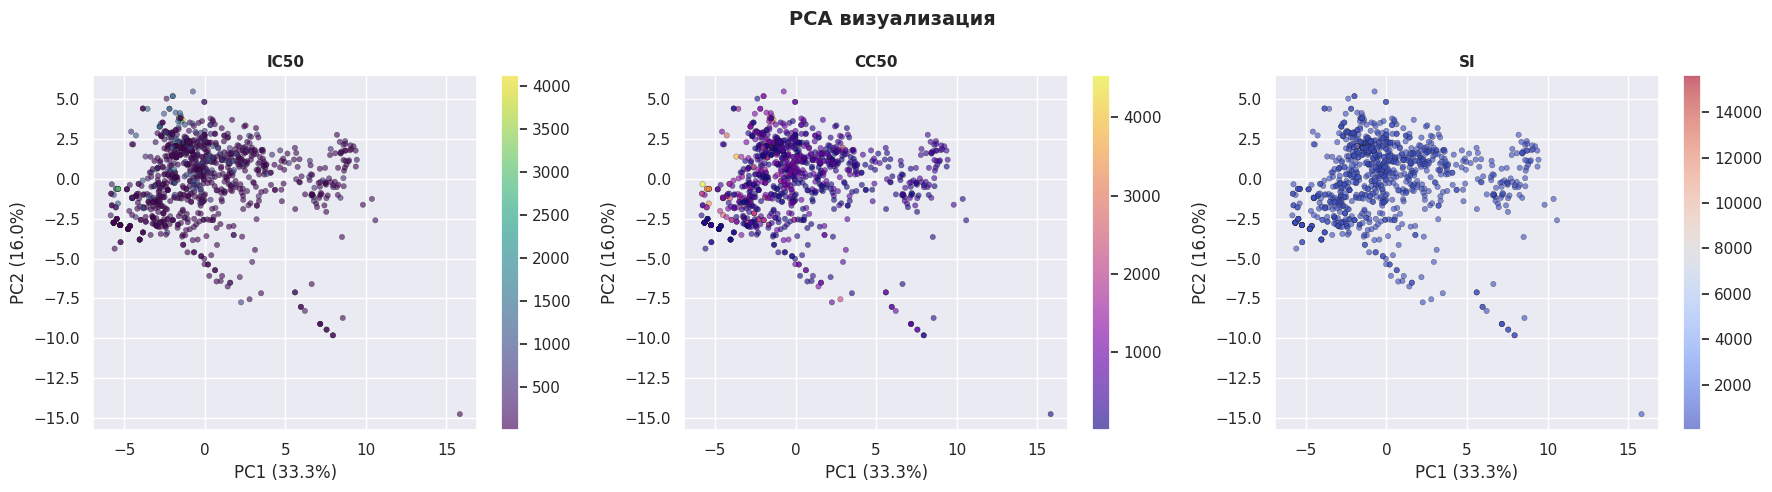

In [69]:
#приведем данные к двумерной структуре через PCA
#cтандартизируем признаки перед PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[feature_cols])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f'Доля объясненной дисперсии: {pca.explained_variance_ratio_}')

#Визулизируем полученные компоненты и целевую переменную
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = {'IC50': 'viridis', 'CC50': 'plasma', 'SI': 'coolwarm'}
titles = {'IC50': 'IC50',
    'CC50': 'CC50',
    'SI': 'SI'}

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['IC50, mM'], cmap=cmaps['IC50'],
                      alpha=0.6, s=15, edgecolors='k', linewidth=0.3)
axes[0].set_title(titles['IC50'], fontsize=11, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['CC50, mM'], cmap=cmaps['CC50'],
                      alpha=0.6, s=15, edgecolors='k', linewidth=0.3)
axes[1].set_title(titles['CC50'], fontsize=11, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(sc2, ax=axes[1])

sc3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['SI'], cmap=cmaps['SI'],
                      alpha=0.6, s=15, edgecolors='k', linewidth=0.3)
axes[2].set_title(titles['SI'], fontsize=11, fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(sc3, ax=axes[2])

plt.suptitle('PCA визуализация', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Доля объясненной дисперсии главными компонентами недостаточная и по графику также визуально не наблюдается линейная зависимость. Для построения моделей будем использовать нелинейные методы

In [70]:
#стандартизируем через другую функцию, не чувствительную к выбросам
scaler = RobustScaler(with_centering=True, with_scaling=True,quantile_range=(25.0, 75.0))
X_scaled_r = scaler.fit_transform(df_final[feature_cols])
y_binary = (df_final['SI'] > 8).astype(int)

In [71]:
#снизим размерность через UMAP, проверим подбор параметров
n_neighbors_options = [20, 25, 30, 40, 50, 70, 100]
min_dist_options = [0.3, 0.5, 0.8, 0.9]
n_components_options = [2, 3, 4, 5, 6, 7]
def umap_selection(X, y, n_components, n_neighbors, min_dist, random_state=42):
  umap_model = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state,
        verbose=False)
  X_umap = umap_model.fit_transform(X)
  #метрика trust - проверяем сохранение локальной структуры
  trust = trustworthiness(X, X_umap, n_neighbors=min(30, len(X)//10))
  #метрика KNN точность - на разных данных одна модель
  knn = KNeighborsClassifier(n_neighbors=5)
  knn_scores = cross_val_score(knn, X_umap, y, cv=5, scoring='accuracy')
  knn_acc = knn_scores.mean()
  return {'n_components': n_components,
        'n_neighbors': n_neighbors,
        'min_dist': min_dist,
        'trustworthiness': trust,
        'knn_accuracy': knn_acc}

results=[]
for n_comp in n_components_options:
    for n_neigh in n_neighbors_options:
        for m_dist in min_dist_options:
            print(f'В тесте: n_comp={n_comp}, n_neigh={n_neigh}, min_dist={m_dist}')
            result = umap_selection(X_scaled_r, y_binary,
                                    n_components=n_comp,
                                    n_neighbors=n_neigh,
                                    min_dist=m_dist)
            results.append(result)


В тесте: n_comp=2, n_neigh=20, min_dist=0.3


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


В тесте: n_comp=2, n_neigh=20, min_dist=0.5


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


В тесте: n_comp=2, n_neigh=20, min_dist=0.8


...

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


В тесте: n_comp=7, n_neigh=100, min_dist=0.8


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


В тесте: n_comp=7, n_neigh=100, min_dist=0.9


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [72]:
results_df = pd.DataFrame(results)
best_for_structure = results_df.loc[results_df['trustworthiness'].idxmax()]
best_for_classification = results_df.loc[results_df['knn_accuracy'].idxmax()]
results_df['combined_score'] = (results_df['trustworthiness'] * 0.5 + results_df['knn_accuracy'] * 0.5)
best_combined = results_df.loc[results_df['combined_score'].idxmax()]
print(f'Лучший результат по сохранению структуры: \n{best_for_structure}')
print(f'\nЛучший результат по KNN точности: \n{best_for_classification}')
print(f'\nЛучший результат по обоим метрикам: \n{best_combined}')

Лучший результат по сохранению структуры: 
n_components        7.000000
n_neighbors        20.000000
min_dist            0.900000
trustworthiness     0.966939
knn_accuracy        0.584231
Name: 143, dtype: float64

Лучший результат по KNN точности: 
n_components        5.000000
n_neighbors        50.000000
min_dist            0.300000
trustworthiness     0.960408
knn_accuracy        0.636291
Name: 100, dtype: float64

Лучший результат по обоим метрикам: 
n_components        5.000000
n_neighbors        50.000000
min_dist            0.300000
trustworthiness     0.960408
knn_accuracy        0.636291
combined_score      0.798350
Name: 100, dtype: float64


по метрикам получаем набор гиперпараметров для UMAP: n_components = 5, n_neighbors = 50, min_dist = 0.3. Выбираем параметры, которые оптимально сохраняют струткту и точность при разделении. Данные в UMAP пространстве разделимы средне, поэтому будут нужны сложные нелинейные модели для дальнейшей работы

In [73]:
#создаем массив с оптимальными UMAP параметрами и сохраняем его в отдельный файл
OPTIMAL_UMAP = {'n_components': 5, 'n_neighbors': 50,'min_dist': 0.3,'random_state': 42}
umap_r = umap.UMAP(**OPTIMAL_UMAP)
X_umap_optimal = umap_r.fit_transform(X_scaled_r)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


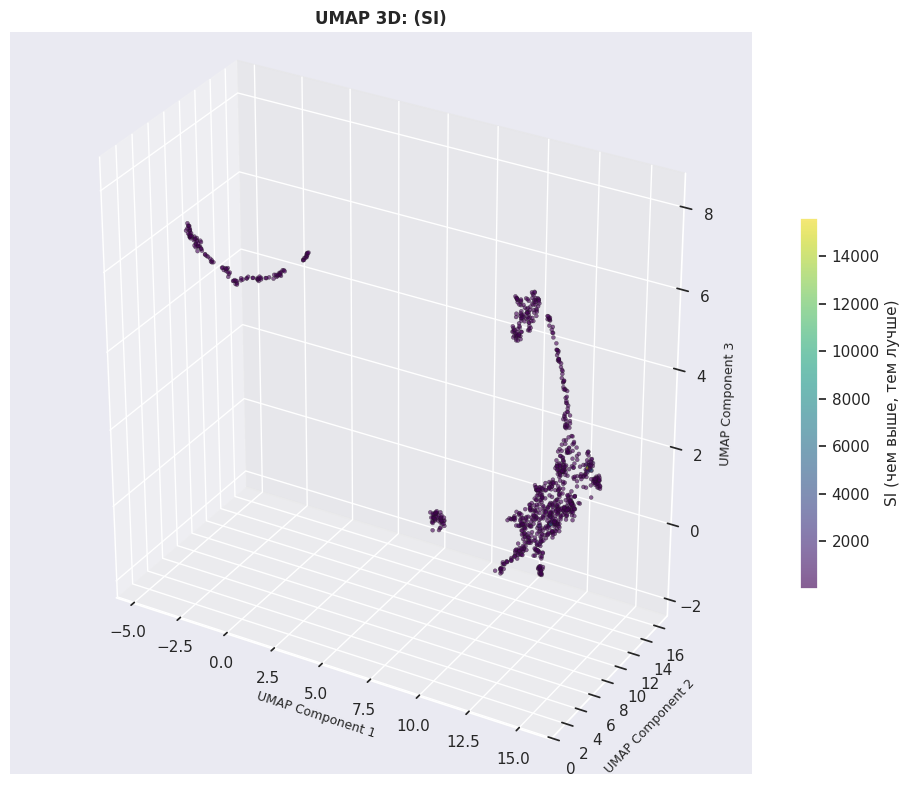

In [74]:
#посмотрим 3д график для первых 3-х компонент
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_umap_optimal[:, 0], X_umap_optimal[:, 1], X_umap_optimal[:, 2],
                c=df['SI'], cmap='viridis', alpha=0.6, s=8, edgecolors='k', linewidth=0.3)
ax.set_box_aspect([2, 1, 2])

ax.set_title('UMAP 3D: (SI)', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP Component 1', fontsize=9)
ax.set_ylabel('UMAP Component 2', fontsize=9)
ax.set_zlabel('UMAP Component 3', fontsize=9)

cbar = plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.05)
cbar.set_label('SI (чем выше, тем лучше)', fontsize=11)

plt.tight_layout()
plt.show()

In [75]:
umap_cols = [f'UMAP{i+1}' for i in range(X_umap_optimal.shape[1])]
umap_target_data = pd.DataFrame(X_umap_optimal, columns=umap_cols)
for target in targets:
    umap_target_data[target] = df_final[target].values
umap_target_data.to_csv('umap_target_data.csv', index=False)
print("\nUMAP-признаки и целевые переменные сохранены в 'umap_target_data.csv'")

umap_all_data = df_final.copy()
for i, col in enumerate(umap_cols):
    umap_all_data[col] = X_umap_optimal[:, i]
umap_all_data.to_csv('umap_all_data.csv', index=False)
print("\nUMAP-признаки, целевые переменные и призаки после обработки сохранены в 'umap_all_data.csv'")


UMAP-признаки и целевые переменные сохранены в 'umap_target_data.csv'

UMAP-признаки, целевые переменные и призаки после обработки сохранены в 'umap_all_data.csv'


In [76]:
df_umap=pd.read_csv('umap_target_data.csv')
df_umap.head(3)

,UMAP1,UMAP2,UMAP3,UMAP4,UMAP5,"IC50, mM","CC50, mM",SI
0,10.696498,15.776585,-0.107648,1.211556,-0.228472,6.239374,175.482382,28.125
1,10.506004,15.888257,0.232621,1.054134,-0.136429,0.771831,5.402819,7.000
2,10.570695,15.903469,0.301640,1.155580,0.004047,223.808778,161.142320,0.720


In [77]:
df_all=pd.read_csv('umap_all_data.csv')
df_all.head(3)

,"IC50, mM","CC50, mM",SI,qed,SPS,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,...,sum_vsa,mean_vsa,std_vsa,sum_slogp,mean_slogp,UMAP1,UMAP2,UMAP3,UMAP4,UMAP5
0,6.239374,175.482382,28.125,0.417362,42.928571,0,0.038844,-0.293526,0.293526,0.038844,...,582.557007,13.547837,23.669733,24.512883,4.085480,10.696498,15.776585,-0.107648,1.211556,-0.228472
1,0.771831,5.402819,7.000,0.462473,45.214286,0,0.012887,-0.313407,0.313407,0.012887,...,596.840153,13.880004,27.090735,35.806772,5.967795,10.506004,15.888257,0.232621,1.054134,-0.136429
2,223.808778,161.142320,0.720,0.260923,42.187500,0,0.094802,-0.325573,0.325573,0.094802,...,714.136318,16.607821,28.247712,62.329944,10.388324,10.570695,15.903469,0.301640,1.155580,0.004047
